In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from lisatools.utils.constants import *
from bbhx.waveformbuild import BBHWaveformFD

No CuPy


In [35]:
def plot_time_domain(time, wave):
   
    plt.figure(figsize=(15, 5))
    plt.plot(time, wave)
    plt.xlabel('Time')
    plt.ylabel('Waveform Amplitude')
    plt.title('Time Domain Waveform')
    plt.grid()
    plt.xlim(time[0], time[-1])
    plt.show()

DAY_SI = 24*3600
MONTH_SI = YRSID_SI/12

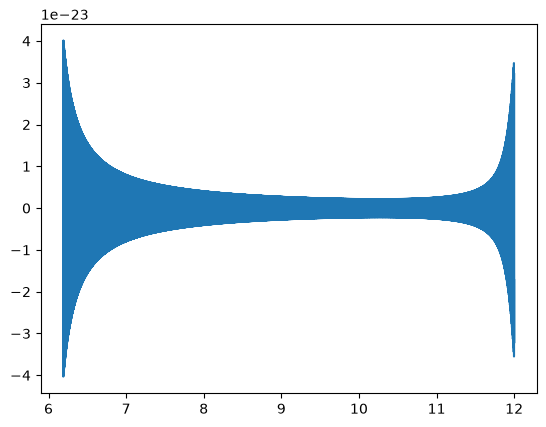

In [41]:
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))

m1 = 1e5
m2 = 2e5
chi1z = 0.0
chi2z = 0.7
dist = 2 * 1e9 * PC_SI
phi_ref = 1.0
f_ref = 0.0
inc = 2*np.pi/3  #2*np.pi/3.
lam = 0
beta= 0
psi = 3*np.pi/8
t_ref = 6*MONTH_SI

modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
Tobs = YRSID_SI

dt = 5.
N = int(Tobs / dt)
Tobs = N * dt
freq = np.fft.rfftfreq(N,dt)
freq[0] = freq[1] # have to do this as freq[0] = 0 causes issues with the waveform generator

wave_freq_domain = wave_gen(m1, m2, chi1z, chi2z,
                            dist, phi_ref, f_ref, inc, lam,
                            beta, psi, t_ref, 
                            freqs=freq, modes=modes, 
                            #t_obs_start=t_obs_start/YRSID_SI, t_obs_end=t_obs_end/YRSID_SI,
                            #shift_t_limits=False,
                            direct=False, fill=True, squeeze=True, length=1024)[0]

wave_time_domain = sp.fft.irfft(wave_freq_domain, axis=-1)
time_array = (np.arange(len(wave_time_domain[1]))*dt)/MONTH_SI

idx_start = len(time_array) // 2  + 100000
idx_end = -1#len(time_array) // 2 + 4000000

plt.plot(time_array[idx_start:], (wave_time_domain[1][idx_start:]))

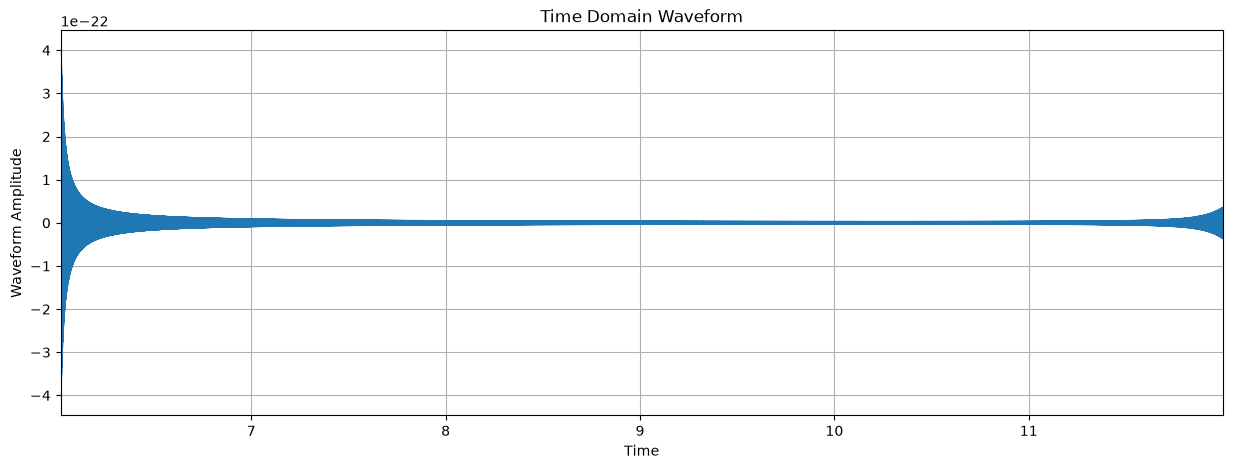

In [8]:
len(wave_time_domain[0])

3681784

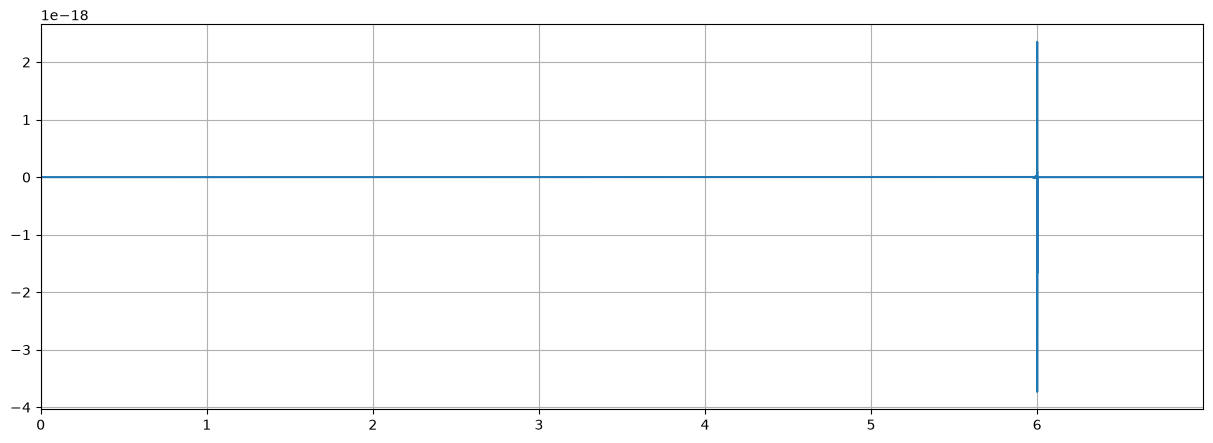

In [12]:
time_array = np.arange(len(wave_time_domain[0]))*dt / MONTH_SI
plt.figure(figsize=(15, 5))
plt.plot(time_array, 
         wave_time_domain[0])
plt.grid()
plt.xlim(time_array[0], time_array[-1])
plt.show()


Text(0, 0.5, '$\\tilde{h}(f)$ (Hz$^{-1/2}$)')

/Users/mprasad/Projects/lisa_modulation_test/.venv/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)


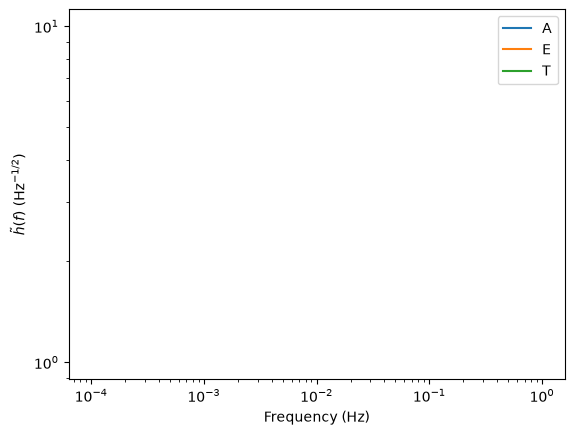

In [71]:
for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freq_new, np.abs(wave_freq_domain[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Text(0, 0.5, '$\\tilde{h}(f)$ (Hz$^{-1/2}$)')

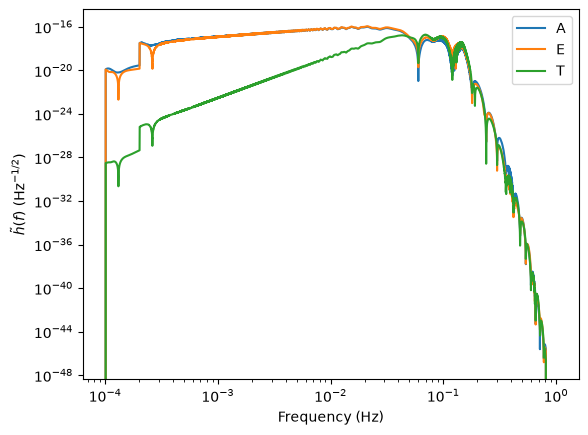

In [74]:
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))

m1 = 1e5
m2 = 2e5
chi1z = 0.0
chi2z = 0.7
dist = 2 * 1e9 * PC_SI
phi_ref = 1.0
f_ref = 0.0
inc = 2*np.pi/3  #2*np.pi/3.
lam = 0
beta= 0
psi = 3*np.pi/8
t_ref = 0.5 * YRSID_SI  # t_ref  (in the SSB reference frame)

# frequencies to interpolate to
freq_new = np.logspace(-4, 0, 10000)
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave = wave_gen(m1, m2, chi1z, chi2z,
                          dist, phi_ref, f_ref, inc, lam,
                          beta, psi, t_ref, freqs=freq_new,
                          modes=modes, direct=False, fill=True, squeeze=True, length=1024)[0]

for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freq_new, np.abs(wave[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")


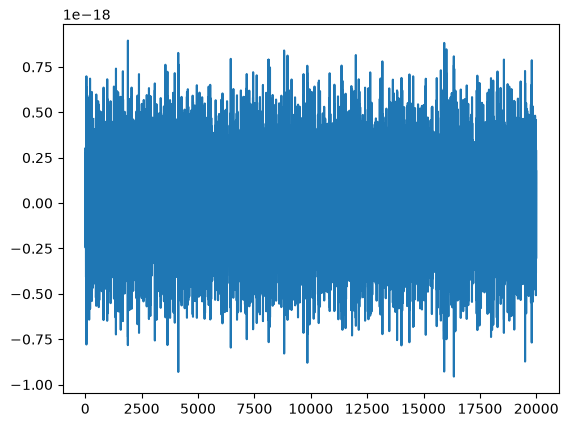

In [ ]:
# start at the beginning of observation
t_obs_start = 0.0

t_obs_end = (t_ref + 1000 * 24 * 3600) / YRSID_SI  # 1 day before merger

wave = wave_gen(m1, m2, chi1z, chi2z,
                          dist, phi_ref, f_ref, inc, lam,
                          beta, psi, t_ref, freqs=freq_new,
                          modes=modes, direct=False, fill=True, squeeze=True, length=1024, t_obs_start=t_obs_start, t_obs_end=t_obs_end)[0]

wave_time_domain = sp.fft.irfft(wave, axis=-1)
plt.plot(wave_time_domain[0])

Text(0, 0.5, '$\\tilde{h}(f)$ (Hz$^{-1/2}$)')

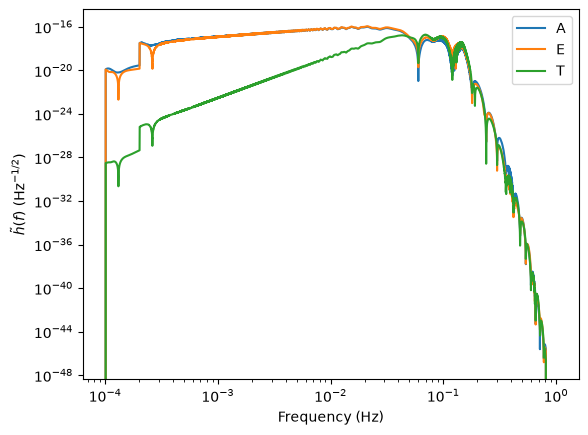

In [90]:
for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freq_new, np.abs(wave[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")

freqs_N: 31558150, freqs_N//2: 15779075


/var/folders/b8/rdglk9j13q9gpzqh2phffrgm0008nc/T/ipykernel_97394/779565955.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


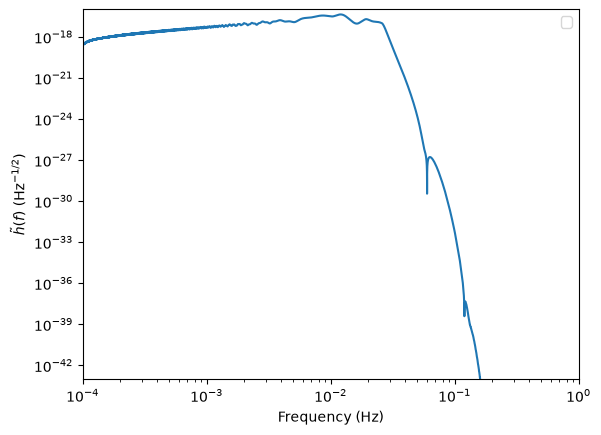

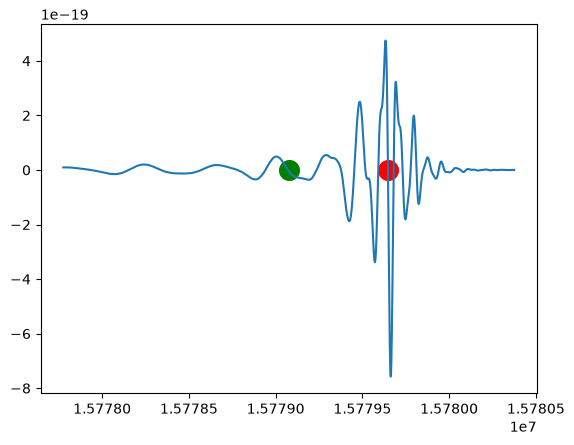

In [13]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from bbhx.waveformbuild import BBHWaveformFD
from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from bbhx.response.fastfdresponse import LISATDIResponse
from bbhx.likelihood import Likelihood, HeterodynedLikelihood
from bbhx.utils.constants import *
from bbhx.utils.transform import *
from lisatools.sensitivity import get_sensitivity
np.random.seed(111222)

# set parameters
f_ref = 0.0  # let phenom codes set f_ref -> fmax = max(f^2A(f))
phi_ref = 0.0 # phase at f_ref
m1 = 1e6
m2 = 5e5
a1 = 0.2
a2 = 0.4
dist = 18e3  * PC_SI * 1e6 # 3e3 in Mpc
inc = np.pi/3.
beta = np.pi/4.  # ecliptic latitude
lam = np.pi/5.  # ecliptic longitude
psi = np.pi/6.  # polarization angle
t_ref = 0.5 * YRSID_SI  # t_ref  (in the SSB reference frame)

fs = 1
Tobs = 1 * YRSID_SI  # 总的观测时间 [s]
freqs_N = int(np.ceil(Tobs * fs).item())  # 观测时间对应的采样点数
print(f"freqs_N: {freqs_N}, freqs_N//2: {freqs_N//2}")
t = np.linspace(0, Tobs, freqs_N, endpoint=False)
dt = (t[1] - t[0]).item()
fs = 1/dt
freqs = np.fft.rfftfreq(freqs_N, d=1/fs)
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))


wave = wave_gen(m1, m2, a1, a2,
    dist, phi_ref, f_ref, inc, lam,
    beta, psi, t_ref, freqs=freqs,
    modes=modes, direct=False, fill=True, squeeze=True, length=1024)[0]

plt.loglog(freqs, np.abs(wave[0]))
plt.xlim(1e-4, 1e-0)
plt.ylim(1e-43, 1e-16)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")
plt.show()


def fft_pad(signal_fd, N_freqs_r, N_freqs, use_gpu=False):
    '''
    把正频部分的信号填充到 N_freqs 的频率域中. \n
    参数: \n
    signal_fd: 频率域信号, 仅正频部分. 频率来自 np.fft.rfftfreq(N_freqs, d=1/fs) \n
    N_freqs_r: 频率域信号的频率点数 \n
    N_freqs: 频率点数, 包含正频和负频, 其中 Nyquist frequency 为负频, fs/2 为 Nyquist frequency
    '''
    if use_gpu:
        import cupy as xp
    else:
        import numpy as np
        xp = np

    if N_freqs_r == N_freqs//2+1:
        pass
    else:
        raise ValueError("N_freqs_r != N_freqs//2 + 1 !")
    signal_fd_fft = xp.zeros(N_freqs, dtype=xp.complex128)
    signal_fd_fft[:N_freqs_r] = signal_fd
    if N_freqs % 2 == 0:
        signal_fd_fft[N_freqs_r-1:] = xp.conj(signal_fd[-1:0:-1])
    else:
        signal_fd_fft[N_freqs_r:] = xp.conj(signal_fd[-1:0:-1])
    return signal_fd_fft


fd_a = wave[0]
fd_a_fft = fft_pad(fd_a, freqs_N//2+1, freqs_N)
td_a = np.fft.ifft(fd_a_fft) * fs

from matplotlib import pyplot as plt
from bbhx.utils.transform import tSSBfromLframe, tLfromSSBframe

t_ref_2 = t_ref + 2 * np.abs(tSSBfromLframe(t_ref, lam, beta) - t_ref)
offset = int(1000 * 1.3 )
start, end = freqs_N//2+1 - offset, freqs_N//2+1 + offset
plt.plot(t[start:end], td_a.real[start:end])
plt.scatter(t_ref, 0, s=200, c='g')
plt.scatter(t_ref_2, 0, s=200, c='r')
plt.show()